# Task 4

## Importing data via the Kaggle API

Using the Kaggle API within SageMaker, the competition data is imported directly and uploaded to an S3 bucket without downloading it to a local machine. This does not require an IAM role with S3 permissions unlike EC2. A SageMaker notebook instance is created with sufficient memory for the training data (ml.m5.xlarge: 4 vCPUs, 16 GiB memory). A GPU is not used as some algorithms (e.g. CatBoost) only train on CPU in SageMaker. CatBoost specifically is memory-bound, so M5, a general-purpose instance, is well suited compared to a compute-optimised instance such as C5. The platform identifier type is notebook-al2-v1 (Amazon Linux 2).

In [1]:
import os
import pandas as pd

In [2]:
!pip install --q git+https://github.com/Kaggle/kaggle-api.git

In [3]:
!mkdir -p ~/.config/kaggle
!echo "{\"username\":\"jarrowsm\",\"key\":\"<my key went here>\"}" > ~/.config/kaggle/kaggle.json
!chmod 600 ~/.config/kaggle/kaggle.json
!kaggle competitions download -c playground-series-s4e7
!unzip -o playground-series-s4e7.zip

 98%|████████████████████████████████████████▎| 243M/247M [00:02<00:00, 196MB/s]
100%|█████████████████████████████████████████| 247M/247M [00:02<00:00, 107MB/s]
Archive:  playground-series-s4e7.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [4]:
args = {'base_dir': '/home/ec2-user/SageMaker/'}

In [5]:
df_train = pd.read_csv(args['base_dir'] + 'train.csv')
df_train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0


### Uploading to S3

With the competition data downloaded into the SageMaker instance, it is uploaded to S3 via Boto3.

In [6]:
import boto3

s3 = boto3.client('s3')
bucket = '297301-a1-task4'
args['bucket_dir'] = f's3://{bucket}'

In [8]:
for f in ['train', 'test', 'sample_submission']:
    print(f"Uploading {f}.csv to {args['bucket_dir']}/kaggle-data/{f}.csv...")
    s3.upload_file(f'{f}.csv', bucket, f'kaggle-data/{f}.csv')

Uploading train.csv to s3://297301-a1-task4/kaggle-data/train.csv...
Uploading test.csv to s3://297301-a1-task4/kaggle-data/test.csv...
Uploading sample_submission.csv to s3://297301-a1-task4/kaggle-data/sample_submission.csv...


In [9]:
def list_bucket_objects(bucket):
    response = s3.list_objects_v2(Bucket=bucket)

    if 'Contents' in response:
        for obj in response['Contents']:
            print(obj['Key'])
    else:
        print(f'No objects in {bucket}.')

In [10]:
list_bucket_objects(bucket)

kaggle-data/sample_submission.csv
kaggle-data/test.csv
kaggle-data/train.csv


## SageMaker Processing

AWS Glue can be use with requisite IAM roles for data preparation and transformation, as data can be read from and written to S3 in an interactive session for feature transformations such as aggregation. The Glue Data Catalog can also be used to organise data for querying from SageMaker. Here, I use SageMaker's built-in data processing capabilities. My script preprocess.py implements the preprocessing from the previous notebook, including stratified sampling, data splitting, data encoding, and undersampling. For this to work in SageMaker, CSV file headers headers are removed. SKLearnProcessor, initialised with the version and managed infrastructure requirements, runs the script with S3 as IO. The run method executes a processing job, passing arguments to the script.

In [20]:
%%writefile preprocess.py

import os
import argparse
import pandas as pd
import numpy as np

def encode_data(df):
    df = df.copy()
    df['Vehicle_Age'] = df['Vehicle_Age'].map({
        "< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})
    
    df['Gender'] = df['Gender'].astype('category')
    df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

    df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes': 1, 'No': 0})
    
    df = df.drop('id', axis=1)

    return df

def split_response(df):
    y = df['Response']
    X = df.drop(columns=['Response'])
    return X, y

def split_data(data, ratio):
    # assumes data is already shuffled
    
    # Split into train and test sets
    isplit = int(len(data) * ratio)
    data_train = data.iloc[:isplit]
    data_test = data.iloc[isplit:].reset_index(drop=True)

    return data_train, data_test

def sample_stratified(N, X, y):
    neg = np.where(y == 0)[0]
    pos = np.where(y == 1)[0]

    N_pos, N_neg = len(pos), len(neg)
    
    pos_ratio = N_pos / (N_pos + N_neg)
    N_pos_sample = int(N * pos_ratio)
    N_neg_sample = N - N_pos_sample

    neg_indices_sample = np.random.choice(neg, size=N_neg_sample, replace=False)
    pos_indices_sample = np.random.choice(pos, size=N_pos_sample, replace=False)
    sample_indices = np.concatenate((neg_indices_sample, pos_indices_sample))

    np.random.shuffle(sample_indices)

    return X.iloc[sample_indices], y.iloc[sample_indices]

def undersample_neg(data, ratio=0.5):
    y = data.iloc[:, 0]

    neg_indices = y[y == 0].index
    pos_indices = y[y == 1].index
    
    N_pos = len(pos_indices)
    N_neg = int(N_pos / ratio - N_pos)

    # Undersample
    neg_sample_indices = neg_indices.to_series().sample(n=N_neg, replace=False, random_state=123).index
    
    sample_indices = pos_indices.append(neg_sample_indices)
    
    data_sample = data.loc[sample_indices]
    data_sample = data_sample.sample(frac=1, random_state=123).reset_index(drop=True)
    
    return data_sample

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--input", type=str, required=True)
    parser.add_argument("--output", type=str, required=True)
    parser.add_argument("--sample", type=str, required=True)
    parser.add_argument("--undersample", type=str, required=True)
    parser.add_argument("--headers", type=str, required=True)

    args = parser.parse_args()
    
    # Load
    input_dir = args.input
    train = pd.read_csv(os.path.join(input_dir, "train.csv"))
    test = pd.read_csv(os.path.join(input_dir, "test.csv"))
    print("Train has shape", train.shape)
    print("Test has shape", test.shape)

    # Process data; SageMaker expects features and labels in the same file, with the target in the first column
    print("Processing data...")
    X_train, y_train = split_response(train)
    X_train_encode = encode_data(X_train)
    X_sample, y_sample = sample_stratified(int(args.sample), X_train_encode, y_train) 
    
    undersample = True if args.undersample == 'y' else False    
    
    train_encode = pd.concat([y_train, X_train_encode], axis=1)
    if undersample: train_encode = undersample_neg(train_encode)
    
    sample = pd.concat([y_sample, X_sample], axis=1)
    sample_train, sample_test = split_data(sample, ratio=0.7)
    sample_val, sample_test = split_data(sample_test, ratio=0.5)
    
    if undersample: sample_train = undersample_neg(sample_train)
    
    test_encode = encode_data(test)

    # Output; SageMaker expects subdirectories train/ and validation/ containing data.csv
    output_dir = args.output
    
    split_dir = os.path.join(output_dir, 'split')
    train_dir = os.path.join(split_dir, 'train')
    val_dir = os.path.join(split_dir, 'validation')
    test_dir = os.path.join(split_dir, 'test')
    
    full_dir = os.path.join(output_dir, 'full')
    train_full_dir = os.path.join(full_dir, 'train')
    test_full_dir = os.path.join(full_dir, 'test')
    
    try:
        os.makedirs(train_dir, exist_ok=True)
        os.makedirs(val_dir, exist_ok=True)
        os.makedirs(test_dir, exist_ok=True)
        os.makedirs(train_full_dir, exist_ok=True)
        os.makedirs(test_full_dir, exist_ok=True)
        print("Successfully found or created output directory.")
    except Exception as e:
        print(e)
        print("Failed to find or create output directory.")
    try:
        headers = True if args.headers == 'y' else False
        train_encode.to_csv(os.path.join(train_full_dir, "data.csv"), index=False, header=headers)
        test_encode.to_csv(os.path.join(test_full_dir, "data.csv"), index=False, header=headers)
        sample_train.to_csv(os.path.join(train_dir, "data.csv"), index=False, header=headers)
        sample_val.to_csv(os.path.join(val_dir, "data.csv"), index=False, header=headers)
        sample_test.to_csv(os.path.join(test_dir, "data.csv"), index=False, header=headers)
        print("Successfully wrote files.")
    except Exception as e:
        print(e)
        print("Failed to write output files.")

Overwriting preprocess.py


In [12]:
import sagemaker

role = sagemaker.get_execution_role()

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/base_serializers.py:28: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 1.22.4)
  import scipy.sparse


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [13]:
from sagemaker.sklearn.processing import SKLearnProcessor

sklearn_processor = SKLearnProcessor(
    framework_version="1.2-1",
    role=role,
    instance_type="ml.m5.xlarge",
    instance_count=1
)

In [14]:
input_dir = f"{args['bucket_dir']}/kaggle-data/"
encoded_dir = args['encoded_dir'] = f"{args['bucket_dir']}/kaggle-data/encoded"

In [21]:
%%capture preprocess_log

from sagemaker.processing import ProcessingInput, ProcessingOutput

sklearn_processor.run(
    code='preprocess.py',
    inputs=[ProcessingInput(source=input_dir, destination='/opt/ml/processing/input')],
    outputs=[ProcessingOutput(source='/opt/ml/processing/output', destination=encoded_dir)],
    arguments=['--input', '/opt/ml/processing/input',
               '--output', '/opt/ml/processing/output',
               '--sample', '500000',
               '--undersample', 'y',
               '--headers', 'n']
)

In [22]:
print(preprocess_log)

..............Train has shape (11504798, 12)
Test has shape (7669866, 11)
Processing data...
Successfully found or created output directory.
Successfully wrote files.




In [23]:
list_bucket_objects(bucket)

kaggle-data/encoded/full/test/data.csv
kaggle-data/encoded/full/train/data.csv
kaggle-data/encoded/split/test/data.csv
kaggle-data/encoded/split/train/data.csv
kaggle-data/encoded/split/validation/data.csv
kaggle-data/sample_submission.csv
kaggle-data/test.csv
kaggle-data/train.csv


In [26]:
print(f"First few rows from {encoded_dir}/split/train/data.csv:")
!aws s3 cp --quiet $encoded_dir/split/train/data.csv - | head -n 3

First few rows from s3://297301-a1-task4/kaggle-data/encoded/split/train/data.csv:
0,69,1,24.0,0,1,1,50570.0,26.0,228,1
1,51,1,15.0,0,1,1,31218.0,124.0,142,1
0,42,1,28.0,0,1,1,34732.0,26.0,249,1


## SageMaker CatBoost

CatBoost performed best in the model benchmark.
SageMaker provides an implementation (catboost-classification-model).
This can be used with various SageMaker features, including
hyperparameter tuning, remote persistance (e.g. for metadata, logs),
hardware scaling, and S3 data sources.
Previously, I used k-fold CV with training fold undersampling.
Here, I use a single hold-out validation
set for simpler compatibility with TrainingInput.
I retrieve the training docker container, algorithm source, and tabular algorithm.

In [28]:
from sagemaker import image_uris, script_uris, model_uris, hyperparameters
from sagemaker.estimator import Estimator
from sagemaker.utils import name_from_base

### Training artifacts

In [29]:
train_model_id = "catboost-classification-model"
train_model_version = "2.1.0"
train_scope = "training"

train_image_uri = image_uris.retrieve(
    region='us-east-1',
    framework='catboost',
    #framework=None,
    model_id=train_model_id,
    model_version=train_model_version,
    image_scope=train_scope,
    instance_type='ml.m5.xlarge',
)

train_source_uri= script_uris.retrieve(
    model_id=train_model_id,
    model_version=train_model_version,
    script_scope=train_scope
)

train_model_uri = model_uris.retrieve(
    model_id=train_model_id, model_version=train_model_version, model_scope=train_scope
)

In [69]:
!mkdir scripts
!aws s3 cp $train_source_uri scripts
!tar -xzf scripts/sourcedir.tar.gz -C scripts
!ls -l scripts

download: s3://jumpstart-cache-prod-us-east-1/source-directory-tarballs/catboost/transfer_learning/classification/prepack/v1.1.1/sourcedir.tar.gz to scripts/sourcedir.tar.gz
total 200292
drwxr-xr-x 2 ec2-user ec2-user      4096 Nov 17  2023 constants
-rw-rw-r-- 1 ec2-user ec2-user         0 Nov 17  2023 __init__.py
drwxr-xr-x 4 ec2-user ec2-user      4096 Nov 17  2023 js_inference_code
drwxr-xr-x 8 ec2-user ec2-user      4096 Nov 17  2023 lib
-rw-r--r-- 1 ec2-user ec2-user       419 Nov 17  2023 requirements.txt
-rw-r--r-- 1 ec2-user ec2-user       182 Nov 17  2023 __script_info__.json
-rw-rw-r-- 1 ec2-user ec2-user       496 Nov 17  2023 script_requirements.txt
-rw-rw-r-- 1 ec2-user ec2-user 205051349 Nov 19  2023 sourcedir.tar.gz
-rw-rw-r-- 1 ec2-user ec2-user     14003 Nov 17  2023 transfer_learning.py
-rw-rw-r-- 1 ec2-user ec2-user         5 Nov 17  2023 version


`transfer_learning.py` is the only entry script available but inspecting the source code confirms it can be used without a pretrained model.

### Training parameters

I set the S3 output path, training instance type, and the algorithm's hyperparameters, and initialise Estimator which will launch the training job.

In [35]:
args

{'base_dir': '/home/ec2-user/SageMaker/',
 'bucket_dir': 's3://297301-a1-task4',
 'encoded_dir': 's3://297301-a1-task4/kaggle-data/encoded'}

In [37]:
s3_output = f"{args['bucket_dir']}/tuning-output"

In [22]:
catparams = hyperparameters.retrieve_default(
    model_id=train_model_id,
    model_version=train_model_version
)

catparams["iterations"] = 100

# Create SageMaker Estimator instance
tabular_estimator = Estimator(
    role=role,
    image_uri=train_image_uri,
    source_dir=train_source_uri,
    model_uri=train_model_uri,
    entry_point='transfer_learning.py',
    instance_count=1,
    instance_type='ml.m5.xlarge',
    max_run=300,
    hyperparameters=catparams,
    output_path=s3_output,
)

print("Initialised CatBoost with the following hyperparameters.\n", catparams)

Initialised CatBoost with the following hyperparameters.
 {'iterations': 100, 'early_stopping_rounds': '5', 'eval_metric': 'Auto', 'learning_rate': '0.03', 'depth': '6', 'l2_leaf_reg': '3', 'random_strength': '1.0', 'max_leaves': '31', 'rsm': '1', 'sampling_frequency': 'PerTreeLevel', 'min_data_in_leaf': '1', 'bagging_temperature': '1', 'boosting_type': 'Auto', 'scale_pos_weight': '1.0', 'max_bin': 'Auto', 'grow_policy': 'SymmetricTree', 'random_seed': '0', 'thread_count': '-1', 'verbose': '1'}


### Start the training job

In [58]:
s3_train = f"{args['encoded_dir']}/split/train"
s3_val = f"{args['encoded_dir']}/split/validation"

In [59]:
data_type = "text/csv"
s3_input_train = sagemaker.TrainingInput(s3_data=s3_train, content_type=data_type)
s3_input_val = sagemaker.TrainingInput(s3_data=s3_val, content_type=data_type)

In [60]:
tabular_estimator.fit(inputs={'training': s3_input_train, 'validation': s3_input_val})

2024-08-24 20:25:55 Starting - Starting the training job...
2024-08-24 20:26:09 Starting - Preparing the instances for training...
2024-08-24 20:26:49 Downloading - Downloading the training image......
2024-08-24 20:27:35 Training - Training image download completed. Training in progress.bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2024-08-24 20:27:44,394 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2024-08-24 20:27:44,396 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2024-08-24 20:27:44,405 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2024-08-24 20:27:44,407 sagemaker_pytorch_container.training INFO     Invoking user training script.
2024-08-24 20:27:46,486 sagemaker-training-toolkit INFO     Installing dependencies from requirements.txt:
/opt/conda/bin/python3.8 -m pip install -r requirements.

### Deploy and perform inference

I query an endpoint and predict probabilities for input samples.

In [43]:
script_scope = "inference"

deploy_image_uri = image_uris.retrieve(
    region='us-east-1',
    framework='catboost',
    image_scope="inference",
    model_id=train_model_id,
    model_version=train_model_version,
    instance_type="ml.m5.xlarge",
)

deploy_source_uri = script_uris.retrieve(
    model_id=train_model_id, model_version=train_model_version, script_scope="inference"
)

In [61]:
endpoint_name = name_from_base(f"inital-{train_model_id}-")

predictor = tabular_estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.xlarge",
    entry_point="inference.py",
    image_uri=deploy_image_uri,
    source_dir=deploy_source_uri,
    endpoint_name=endpoint_name
)

------!

I download the stratified sample test data for inference.

In [64]:
s3.download_file(bucket, f"kaggle-data/encoded/split/test/data.csv", "sample_test.csv")

test_data = pd.read_csv("sample_test.csv", header=None)
test_data.columns = ["Reponse"] + [f"Feature {i}" for i in range(test_data.shape[1] - 1)]

test_data.head()

,Reponse,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9
0,0,23,1,10.0,1,0,0,23054.0,151.0,248,0
1,0,44,1,9.0,0,2,1,37762.0,124.0,143,0
2,0,34,1,18.0,1,1,0,25440.0,124.0,160,1
3,0,23,1,29.0,1,0,0,32905.0,152.0,131,0
4,0,43,1,8.0,0,1,1,43179.0,26.0,107,0


I query the endpoint for predictions. This provides an array of probabilities for each class.
I write a function to perform this in batches which will be helpful for the full test dataset.
The test data has to be converted to a CSV without headers for inference. I remove ground truth labels and run inference on the features.

In [48]:
import json
import numpy as np

def get_pred_from_endpoint(endpoint_name, features, batch_size=5000):
    client = boto3.client("runtime.sagemaker")
    probs = []
    
    for i in np.arange(0, len(features), step=batch_size):
        data = features.iloc[i : (i + batch_size), :].to_csv(header=False, index=False)
        response = client.invoke_endpoint(
            EndpointName=endpoint_name, ContentType="text/csv", 
            Body=data
        )
        pred = json.loads(response["Body"].read())['probabilities']
        probs.append(np.array(pred))
    
    probs = np.concatenate(probs, axis=0)
    
    return probs[:,1]


In [66]:
ground_truth_label, features = test_data.iloc[:, 0], test_data.iloc[:, 1:]

probs = get_pred_from_endpoint(endpoint_name, features)
print(probs.shape)
probs

(75000,)


array([0.32758948, 0.5902038 , 0.32905189, ..., 0.54416941, 0.38330663,
       0.58924437])

In [67]:
calculate_metrics(probs, ground_truth_label)

{'precision': 0.2775664162845901,
 'recall': 0.9323866739486619,
 'f1': 0.42778390297684676,
 'accuracy': 0.69552,
 'mcc': 0.3960064057649636,
 'kappa': 0.2951888310602443,
 'lift': 2.2738919957776362,
 'roc_auc': 0.8458070981537786,
 'balanced_log_loss': 0.5600344040032421}

Low precision indicates many FPs with only 27.8% of positive predictions correct. Recall is high at 93.2% (most TPs identified), good for detecting customers.
This results in a moderate F1 score. MCC (0.396) shows moderate correlation between predicted and actual labels, and Cohen's Kappa (0.295) is above random but limited.
Lift indicates that the model is 2.27 times more likely to find positive samples than random selection, a generally good score.
ROC/AUC is high showing strong class separation, but balanced log loss is moderate, indicating scope for improvement.
Overall, the initial CatBoost identifies positives well but produces many FPs, so tuning is warrented.

## Hyperparameter Tuning

### Perform a tuning job

SageMaker provides tuning via HyperparameterTuner to interact with tuning APIs. This uses a hold-out validation set comprised of 15% of the 500k stratified sample.
I use the same hyperparameter space as in 02_model_benchmark.ipynb, plus
subsample and colsample_bylevel. Subsample (0.5 - 1.0), controls the proportion of training samples used by each tree, and colsample_bylevel (0.5 - 1.0) is similar, but also adds randomness to feature selection to potentially reduce overfitting.

In [86]:
tuning_estimator = Estimator(
    role=role,
    image_uri=train_image_uri,
    source_dir=train_source_uri,
    model_uri=train_model_uri,
    entry_point='transfer_learning.py',
    instance_count=1,
    instance_type='ml.m5.xlarge',
    max_run=360000,
    hyperparameters=catparams,
    output_path=s3_output,
)

In [90]:
from sagemaker.tuner import ContinuousParameter, IntegerParameter, HyperparameterTuner

hyperparameter_ranges = {
    "learning_rate": ContinuousParameter(0.01, 0.1, scaling_type="Logarithmic"),
    "depth": IntegerParameter(5, 10),
    "random_strength": ContinuousParameter(0.1, 10, scaling_type="Logarithmic"),
    "l2_leaf_reg": ContinuousParameter(0.1, 10, scaling_type="Logarithmic"),
    "iterations": IntegerParameter(50, 1000),
    "early_stopping_rounds": IntegerParameter(1, 10),
    "bagging_temperature": ContinuousParameter(0, 0.5),
    "border_count": IntegerParameter(32, 255),
    "one_hot_max_size": IntegerParameter(2, 10),
    "leaf_estimation_iterations": IntegerParameter(1, 5),
    "subsample": ContinuousParameter(0.5, 1.0),
    "colsample_bylevel": ContinuousParameter(0.5, 1.0),
}

tuner = HyperparameterTuner(
        estimator=tuning_estimator,
        objective_metric_name="AUC",
        hyperparameter_ranges=hyperparameter_ranges,
        metric_definitions=[{"Name": "AUC", "Regex": "bestTest = ([0-9\\.]+)"}],
        strategy='Bayesian',
        max_jobs=50,
        max_parallel_jobs=4,
        objective_type="Maximize"
)

In [91]:
tuner.fit({'training': s3_input_train, 'validation': s3_input_val}, logs=True)

.............................................................................................................................................................................................................................!


### Analyse the results

#### Retrieve tuning results

In [92]:
tuner_name = tuner.latest_tuning_job.name

In [108]:
client = boto3.client("sagemaker")

tuning_job_result = client.describe_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuner_name
)

I can use this to show the number of best training jobs from the search:

In [143]:
tuner = sagemaker.HyperparameterTuningJobAnalytics(tuner_name)
tuner_df = tuner.dataframe()
tuner_df = tuner_df.sort_values("FinalObjectiveValue", ascending=False)

print(f"Completed {len(tuner_df)} trianing jobs")
print("lowest AUC:", min(tuner_df["FinalObjectiveValue"]), "highest AUC:", max(tuner_df["FinalObjectiveValue"]))

pd.set_option("display.max_colwidth", None)
tuner_df.head()

Completed 50 trianing jobs
lowest AUC: 0.8461127281188965 highest AUC: 0.8718025088310242


,bagging_temperature,border_count,colsample_bylevel,depth,early_stopping_rounds,iterations,l2_leaf_reg,leaf_estimation_iterations,learning_rate,one_hot_max_size,random_strength,subsample,TrainingJobName,TrainingJobStatus,FinalObjectiveValue,TrainingStartTime,TrainingEndTime,TrainingElapsedTimeSeconds
8,0.241902,187.0,0.816531,5.0,9.0,716.0,1.082203,4.0,0.087993,8.0,9.043290,0.667992,sagemaker-jumpstart-240824-2119-042-e0981b9e,Completed,0.871803,2024-08-24 21:34:33+00:00,2024-08-24 21:35:32+00:00,59.0
6,0.144420,36.0,0.887778,5.0,9.0,593.0,2.316428,1.0,0.091330,5.0,1.041340,0.515102,sagemaker-jumpstart-240824-2119-044-6e38d4fc,Completed,0.871339,2024-08-24 21:35:08+00:00,2024-08-24 21:36:02+00:00,54.0
11,0.210738,239.0,0.618069,5.0,9.0,467.0,9.265215,5.0,0.082114,5.0,0.280667,0.503935,sagemaker-jumpstart-240824-2119-039-92edfa0d,Completed,0.871166,2024-08-24 21:33:29+00:00,2024-08-24 21:34:27+00:00,58.0
19,0.297200,247.0,0.669710,7.0,9.0,507.0,2.544891,5.0,0.091496,6.0,0.153079,0.557775,sagemaker-jumpstart-240824-2119-031-0674b5fd,Completed,0.870999,2024-08-24 21:30:39+00:00,2024-08-24 21:31:33+00:00,54.0
16,0.158485,252.0,0.828647,5.0,8.0,989.0,3.551159,1.0,0.086663,9.0,3.116062,0.576447,sagemaker-jumpstart-240824-2119-034-495c02f4,Completed,0.870886,2024-08-24 21:31:52+00:00,2024-08-24 21:32:51+00:00,59.0


Job 8 achieved best validation AUC with the following hyperparameters:

In [169]:
best_params = tuner_df.iloc[0]
best_hyperparameters = best_params[:12].to_dict()
best_hyperparameters

{'bagging_temperature': 0.24190238404152065,
 'border_count': 187.0,
 'colsample_bylevel': 0.8165313582470207,
 'depth': 5.0,
 'early_stopping_rounds': 9.0,
 'iterations': 716.0,
 'l2_leaf_reg': 1.082202629168751,
 'leaf_estimation_iterations': 4.0,
 'learning_rate': 0.0879927731968765,
 'one_hot_max_size': 8.0,
 'random_strength': 9.043289801458402,
 'subsample': 0.6679918979888417}

#### AUC over time

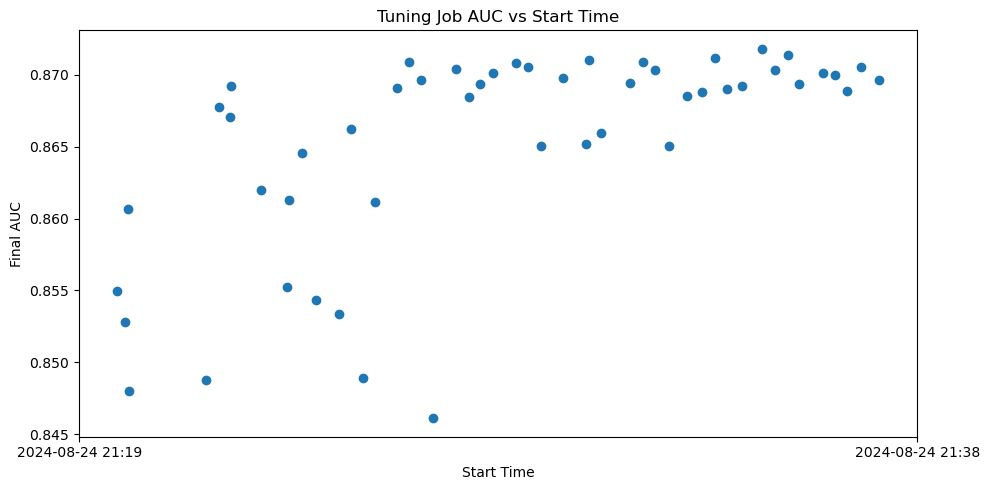

In [133]:
import matplotlib.dates as mdates

plt.figure(figsize=(10, 5))

plt.scatter(tuner_df['TrainingStartTime'], tuner_df['FinalObjectiveValue'])
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())

plt.title('Tuning Job AUC vs Start Time')
plt.xlabel('Start Time')
plt.ylabel('Final AUC')

plt.tight_layout()
plt.show()

The plot above show AUC values as the tuning job progresses (tuning was asynchronous).
There is an unsteady trend towards higher AUC as the Bayesian algorithm balances searching new
areas of the parameter space with known good areas. The plateau indicates that 50 jobs is sufficient for the search space.

#### Refining the search space

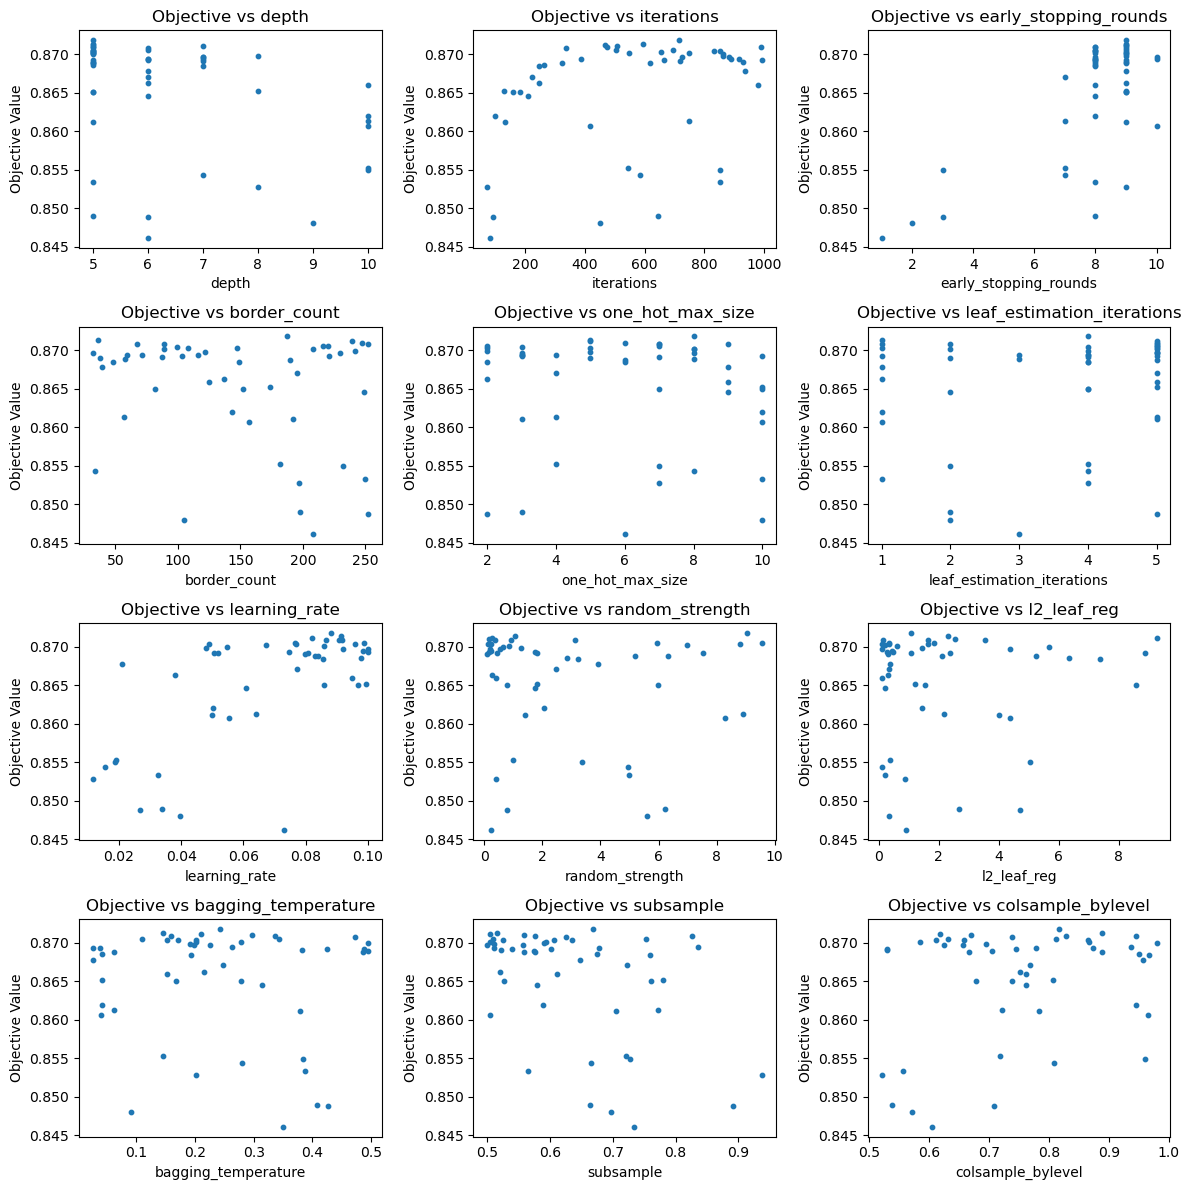

In [142]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

for i, (name, _) in enumerate(tuner.tuning_ranges.items()):
    ax = axes[i]
    ax.scatter(tuner_df[name], tuner_df["FinalObjectiveValue"], s=10)
    ax.set_xlabel(name)
    ax.set_ylabel("Objective Value")
    ax.set_title(f"Objective vs {name}")

plt.tight_layout()
plt.show()

The plots show how individual hyperparameters affect AUC and help identify candidates for further search.
Learning rate has a positive trend with more points near 0.1, the upper bound of the initial search, which suggests exetnding the search to higher values.
A similar pattern is observed for early stopping.
A refined search is conducted using the best hyperparameters from the previous search to further improve ROC/AUC.

In [219]:
for k, v in best_hyperparameters.items():
    if isinstance(v, float) and v.is_integer():
        best_hyperparameters[k] = int(v)

catparams2 = catparams.copy()

for key in best_hyperparameters:
    catparams2[key] = best_hyperparameters[key]

In [222]:
catparams2

{'iterations': 716,
 'early_stopping_rounds': 9,
 'eval_metric': 'Auto',
 'learning_rate': 0.0879927731968765,
 'depth': 5,
 'l2_leaf_reg': 1.082202629168751,
 'random_strength': 9.043289801458402,
 'max_leaves': '31',
 'rsm': '1',
 'sampling_frequency': 'PerTreeLevel',
 'min_data_in_leaf': '1',
 'bagging_temperature': 0.24190238404152065,
 'boosting_type': 'Auto',
 'scale_pos_weight': '1.0',
 'max_bin': 'Auto',
 'grow_policy': 'SymmetricTree',
 'random_seed': '0',
 'thread_count': '-1',
 'verbose': '1',
 'border_count': 187,
 'colsample_bylevel': 0.8165313582470207,
 'leaf_estimation_iterations': 4,
 'one_hot_max_size': 8,
 'subsample': 0.6679918979888417}

In [223]:
hyperparameter_ranges2 = {
    "learning_rate": ContinuousParameter(0.05, 1.0, scaling_type="Logarithmic"),
    "early_stopping_rounds": IntegerParameter(8, 50)
}

tuning_estimator2 = Estimator(
    role=role,
    image_uri=train_image_uri,
    source_dir=train_source_uri,
    model_uri=train_model_uri,
    entry_point='transfer_learning.py',
    instance_count=1,
    instance_type='ml.m5.xlarge',
    max_run=360000,
    hyperparameters=catparams2,
    output_path=s3_output
)

tuner2 = HyperparameterTuner(
    estimator=tuning_estimator2,
    objective_metric_name="AUC",
    hyperparameter_ranges=hyperparameter_ranges2,
    metric_definitions=[{"Name": "AUC", "Regex": "bestTest = ([0-9\\.]+)"}],
    strategy='Bayesian',
    max_jobs=10,
    max_parallel_jobs=4,
    objective_type="Maximize"
)

In [224]:
tuner2.fit({'training': s3_input_train, 'validation': s3_input_val}, logs=True)

..................................................................!


In [ ]:
tuner_name2 = tuner2.latest_tuning_job.name

In [236]:
tuning_job_result2 = client.describe_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuner_name2
)
tuner2 = sagemaker.HyperparameterTuningJobAnalytics(tuner_name2)
tuner_df2 = tuner2.dataframe()
tuner_df2 = tuner_df2.sort_values("FinalObjectiveValue", ascending=False)

print(f"Completed {len(tuner_df2)} trianing jobs")
print("lowest AUC:", min(tuner_df2["FinalObjectiveValue"]), "highest AUC:", max(tuner_df2["FinalObjectiveValue"]))

pd.set_option("display.max_colwidth", None)
tuner_df2.head()

Completed 10 trianing jobs
lowest AUC: 0.8698158860206604 highest AUC: 0.8721281290054321


,early_stopping_rounds,learning_rate,TrainingJobName,TrainingJobStatus,FinalObjectiveValue,TrainingStartTime,TrainingEndTime,TrainingElapsedTimeSeconds
3,41.0,0.095486,sagemaker-jumpstart-240825-0000-007-db3cbc67,Completed,0.872128,2024-08-25 00:03:56+00:00,2024-08-25 00:04:55+00:00,59.0
1,28.0,0.107043,sagemaker-jumpstart-240825-0000-009-8f3a01a6,Completed,0.871969,2024-08-25 00:05:00+00:00,2024-08-25 00:06:04+00:00,64.0
7,28.0,0.088570,sagemaker-jumpstart-240825-0000-003-aa622d48,Completed,0.871938,2024-08-25 00:01:37+00:00,2024-08-25 00:03:39+00:00,122.0
8,23.0,0.115540,sagemaker-jumpstart-240825-0000-002-60f95ebf,Completed,0.871878,2024-08-25 00:01:35+00:00,2024-08-25 00:03:29+00:00,114.0
6,30.0,0.068078,sagemaker-jumpstart-240825-0000-004-bbc8ecca,Completed,0.871298,2024-08-25 00:01:56+00:00,2024-08-25 00:03:55+00:00,119.0


In [259]:
bestparams2 = tuner_df2.iloc[0][['early_stopping_rounds', 'learning_rate']].to_dict()
bestparams2['early_stopping_rounds'] = int(bestparams2['early_stopping_rounds'])
bestauc2 = tuner_df2.iloc[0]['FinalObjectiveValue']
print(bestparams2, 'achieved ROC/AUC score', bestauc2)

{'early_stopping_rounds': 41, 'learning_rate': 0.09548575668657439} achieved ROC/AUC score 0.8721281290054321


Further tuning finds the optimal learning rate as 0.095 with 41 early stopping rounds.
This indicates that extending the learning rate range beyond 0.1 was unnecessary, while increasing the early stopping rounds was beneficial.
The learning rate values remain concentrated near 0.1 with one job near 0.5 performing poorly. In contrast, higher early stopping values are searched and contribute to improved performance.

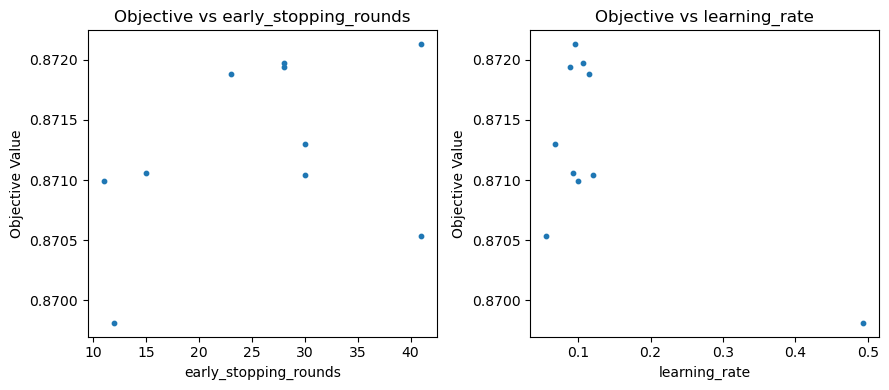

In [251]:
ranges2 = tuner2.tuning_ranges

N_plots = len(ranges2)
N_cols = 2
N_rows = 1

fig, axes = plt.subplots(N_rows, N_cols, figsize=(9,4))
axes = axes.flatten()

for i, (name, _) in enumerate(ranges2.items()):
    ax = axes[i]
    ax.scatter(tuner_df2[name], tuner_df2["FinalObjectiveValue"], s=10)
    ax.set_xlabel(name)
    ax.set_ylabel("Objective Value")
    ax.set_title(f"Objective vs {name}")
favoured
plt.tight_layout()
plt.show()

In [37]:
best_hyperparameters2

{'bagging_temperature': 0.24190238404152065,
 'border_count': 187,
 'colsample_bylevel': 0.8165313582470207,
 'depth': 5,
 'early_stopping_rounds': 41,
 'iterations': 716,
 'l2_leaf_reg': 1.082202629168751,
 'leaf_estimation_iterations': 4,
 'learning_rate': 0.09548575668657439,
 'one_hot_max_size': 8,
 'random_strength': 9.043289801458402,
 'subsample': 0.6679918979888417}

In [48]:
from pprint import pprint
catparams3 = catparams2.copy()

# update learning rate and early stopping
for k in bestparams2:
    catparams3[k] = bestparams2[k]
    
pprint(catparams3)
print("ROC/AUC on sample test set:", bestauc2)

{'bagging_temperature': 0.24190238404152065,
 'boosting_type': 'Auto',
 'border_count': 187,
 'colsample_bylevel': 0.8165313582470207,
 'depth': 5,
 'early_stopping_rounds': 41,
 'eval_metric': 'Auto',
 'grow_policy': 'SymmetricTree',
 'iterations': 716,
 'l2_leaf_reg': 1.082202629168751,
 'leaf_estimation_iterations': 4,
 'learning_rate': 0.09548575668657439,
 'max_bin': 'Auto',
 'max_leaves': '31',
 'min_data_in_leaf': '1',
 'one_hot_max_size': 8,
 'random_seed': '0',
 'random_strength': 9.043289801458402,
 'rsm': '1',
 'sampling_frequency': 'PerTreeLevel',
 'scale_pos_weight': '1.0',
 'subsample': 0.6679918979888417,
 'thread_count': '-1',
 'verbose': '1'}
ROC/AUC on sample test set: 0.8721281290054321


The first tuning job increased AUC significantly from 0.8458 to 0.8718, while the second gives a further slight improvement to 0.8721.

## Full training

SageMaker automatically divides data into training and validation sets.

In [40]:
s3_train_full = f"{args['encoded_dir']}/full/train"
s3_output_full = f"{args['bucket_dir']}/final-output"

final_estimator = Estimator(
    role=role,
    image_uri=train_image_uri,
    source_dir=train_source_uri,
    model_uri=train_model_uri,
    entry_point='transfer_learning.py',
    instance_count=1,
    instance_type='ml.m5.xlarge',
    max_run=360000,
    hyperparameters=catparams3,
    output_path=s3_output,
)

In [41]:
final_estimator.fit(inputs={'training': s3_train_full})

2024-08-25 19:05:15 Starting - Starting the training job...
2024-08-25 19:05:49 Starting - Preparing the instances for training...
2024-08-25 19:06:20 Downloading - Downloading input data...
2024-08-25 19:06:45 Downloading - Downloading the training image...
2024-08-25 19:07:21 Training - Training image download completed. Training in progress...bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2024-08-25 19:07:30,580 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2024-08-25 19:07:30,581 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2024-08-25 19:07:30,590 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2024-08-25 19:07:30,592 sagemaker_pytorch_container.training INFO     Invoking user training script.
2024-08-25 19:07:32,535 sagemaker-training-toolkit INFO     Installing dependencies from requirements.tx

Deploying the model:

In [44]:
final_endpoint_name = name_from_base(f"jumpstart-{train_model_id}-full")

final_predictor = final_estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.xlarge",
    entry_point="inference.py",
    image_uri=deploy_image_uri,
    source_dir=deploy_source_uri,
    endpoint_name=final_endpoint_name
)

------!

Retrieving the test data:

In [45]:
s3.download_file(bucket, "kaggle-data/encoded/full/test/data.csv", "test_encode_full.csv")
test_full = pd.read_csv("test_encode_full.csv", header=None)

Obtaining probabilities from the endpoint:

In [ ]:
probs_full = get_pred_from_endpoint(final_endpoint_name, test_full, batch_size=100000)
probs_full.shape

Formatting the submission:

In [49]:
submission = pd.concat([pd.read_csv("test.csv")['id'], pd.Series(probs_full)], axis=1).rename(columns={0: 'Response'})
submission.head()

,id,Response
0,11504798,0.063289
1,11504799,0.804864
2,11504800,0.699235
3,11504801,0.000803
4,11504802,0.268438


Submitting to Kaggle via the API:

In [50]:
submission.to_csv('submission.csv', index=False)
!kaggle competitions submit -c playground-series-s4e7 -f submission.csv -m "SageMaker CatBoost v1"

100%|████████████████████████████████████████| 214M/214M [00:03<00:00, 72.2MB/s]
Successfully submitted to Binary Classification of Insurance Cross Selling 

In [54]:
!kaggle competitions submissions -c playground-series-s4e7 | head -n 3

fileName                                            date                 description                                   status    publicScore  privateScore  
--------------------------------------------------  -------------------  --------------------------------------------  --------  -----------  ------------  
submission.csv                                      2024-08-25 19:30:05  SageMaker CatBoost v1                         complete  0.87643      0.87614       


SageMaker CatBoost obtains a (public) competition score of 0.87662.

## Autopilot

Autopilot is an automated machine learning (AutoML) solution for building, training, and tuning ML models with tabular data.
It automates data inspection, preprocessing, algorithm selection, and hyperparameter tuning, and can be used with or without human guidance. Here I use Autopilot through the AWS SDK with data stored in S3 (it can also be used without code in SageMaker Studio).
Unlike in previous steps, Autopilot expects the data to have a header row.
I provide a 100k stratified sample of the original dataset without additional processing to demonstrate Autopilot's sampling, cleaning, and prepocessing capabilities.

### Creating an unprocessed sample

In [93]:
%%writefile strat_sample.py
import os
import argparse
import pandas as pd
import numpy as np


def sample_stratified(N, X, y):
    neg = np.where(y == 0)[0]
    pos = np.where(y == 1)[0]

    N_pos, N_neg = len(pos), len(neg)
    
    pos_ratio = N_pos / (N_pos + N_neg)
    N_pos_sample = int(N * pos_ratio)
    N_neg_sample = N - N_pos_sample

    neg_indices_sample = np.random.choice(neg, size=N_neg_sample, replace=False)
    pos_indices_sample = np.random.choice(pos, size=N_pos_sample, replace=False)
    sample_indices = np.concatenate((neg_indices_sample, pos_indices_sample))

    np.random.shuffle(sample_indices)

    return X.iloc[sample_indices]


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--input", type=str, required=True)
    parser.add_argument("--output", type=str, required=True)
    parser.add_argument("--sample", type=str, required=True)

    args = parser.parse_args()
    
    # Load
    input_dir = args.input
    data = pd.read_csv(os.path.join(input_dir, "train.csv"))
    print("Train has shape", data.shape)

    # Process data; SageMaker expects features and labels in the same file, with the target in the first column
    print("Processing data...")
    sample = sample_stratified(int(args.sample), data, data['Response']) 

    output_dir = args.output
    sample_dir = os.path.join(output_dir, 'unprocessed_sample')
    train_dir = os.path.join(sample_dir, 'train')
    
    try:
        os.makedirs(train_dir, exist_ok=True)
        print("Successfully found or created output directory.")
    except Exception as e:
        print(e)
        print("Failed to find or create output directory.")
    try:
        sample.to_csv(os.path.join(train_dir, "train_sample.csv"), index=False)
        print("Successfully wrote file.")
    except Exception as e:
        print(e)
        print("Failed to write output file.")


Writing strat_sample.py


In [102]:
input_dir = output_dir = f"{args['bucket_dir']}/kaggle-data"

In [94]:
%%capture preprocess_log2

sklearn_processor.run(
    code='strat_sample.py',
    inputs=[ProcessingInput(source=input_dir, destination='/opt/ml/processing/input')],
    outputs=[ProcessingOutput(source='/opt/ml/processing/output', destination=output_dir)],
    arguments=['--input', '/opt/ml/processing/input',
               '--output', '/opt/ml/processing/output',
               '--sample', '100000']
)

In [95]:
print(preprocess_log2)

.............................Train has shape (11504798, 12)
Processing data...
Successfully found or created output directory.
Successfully wrote file.




In [105]:
unprocessed_sample_dir = f'{output_dir}/unprocessed_sample/train'

In [106]:
print(f"First rows from {unprocessed_sample_dir}/train_sample.csv:")
!aws s3 cp --quiet $unprocessed_sample_dir/train_sample.csv - | head -n 10

First rows from s3://297301-a1-task4/kaggle-data/unprocessed_sample/train/train_sample.csv:
id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
6143240,Male,46,1,28.0,0,1-2 Year,Yes,56688.0,26.0,86,0
8197715,Female,52,1,31.0,0,1-2 Year,Yes,2630.0,124.0,86,0
6558120,Male,69,1,39.0,0,1-2 Year,Yes,34376.0,26.0,101,0
10691949,Male,23,1,18.0,0,< 1 Year,Yes,27544.0,152.0,244,0
7794438,Male,39,1,48.0,1,1-2 Year,Yes,2630.0,157.0,269,0
9147886,Female,24,1,28.0,1,< 1 Year,No,57834.0,152.0,221,0
3401474,Male,42,1,28.0,0,1-2 Year,Yes,60937.0,122.0,299,1
4074438,Male,31,1,46.0,1,< 1 Year,No,28846.0,152.0,217,0
7286284,Female,67,1,3.0,0,1-2 Year,Yes,2630.0,30.0,196,0


Shown above, the data is not processed. I configure an Autopilot job with 20 candidates which is launched via create_auto_ml_job.

In [107]:
input_data_config = [
    {
        "DataSource": {
            "S3DataSource": {
                "S3DataType": "S3Prefix",
                "S3Uri": unprocessed_sample_dir,
            }
        },
        "TargetAttributeName": "Response",
    }
]
output_data_config = {"S3OutputPath": f"{args['bucket_dir']}/automl-unprocessed100k-output"}
problem_type = "BinaryClassification"
job_objective = {"MetricName": "AUC"}
job_config = {"CompletionCriteria": {"MaxCandidates": 20}}

In [108]:
sm = boto3.Session().client(service_name="sagemaker", region_name="us-east-1")
autopilot_job_name = "unprocessed-sample-automl-job"
sm.create_auto_ml_job(
    AutoMLJobName=autopilot_job_name,
    InputDataConfig=input_data_config,
    OutputDataConfig=output_data_config,
    ProblemType=problem_type,
    AutoMLJobObjective=job_objective,
    AutoMLJobConfig=job_config,
    RoleArn=role
)

{'AutoMLJobArn': 'arn:aws:sagemaker:us-east-1:470186945047:automl-job/unprocessed-sample-automl-job',
 'ResponseMetadata': {'RequestId': '8961c97f-9d36-4442-8dde-9387e862be9d',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '8961c97f-9d36-4442-8dde-9387e862be9d',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '100',
   'date': 'Sun, 25 Aug 2024 20:52:19 GMT'},
  'RetryAttempts': 0}}

### Tracking progress

Autopilot operates in three stages:
- *data analysis* analyses the data to find potential pipelines and splits the data
- *feature engineering* transforms individual and aggregated features
- *tuning* selects the optimal pipeline and hyperparameters

In [ ]:
from datetime import datetime
from time import sleep

automl_response = sm.describe_auto_ml_job(AutoMLJobName=autopilot_job_name)
job_status = automl_response["AutoMLJobStatus"]

while job_status not in ("Failed", "Completed", "Stopped"):
    automl_response = sm.describe_auto_ml_job(AutoMLJobName=autopilot_job_name)
    secondary_status = automl_response["AutoMLJobSecondaryStatus"]
    job_status = automl_response["AutoMLJobStatus"]
    print(f"{datetime.now().strftime('%H:%M:%S')} - {secondary_status}: {job_status}")

    sleep(60)

20:52:20 - AnalyzingData: InProgress
20:53:20 - AnalyzingData: InProgress
20:54:21 - AnalyzingData: InProgress
20:55:21 - AnalyzingData: InProgress
20:56:21 - AnalyzingData: InProgress
20:57:21 - AnalyzingData: InProgress
20:58:21 - AnalyzingData: InProgress
20:59:21 - AnalyzingData: InProgress
21:00:22 - AnalyzingData: InProgress
21:01:22 - FeatureEngineering: InProgress
21:02:22 - FeatureEngineering: InProgress
21:03:22 - FeatureEngineering: InProgress
21:04:22 - FeatureEngineering: InProgress
21:05:23 - FeatureEngineering: InProgress
21:06:23 - FeatureEngineering: InProgress
21:07:23 - FeatureEngineering: InProgress
21:08:23 - FeatureEngineering: InProgress
21:09:23 - ModelTuning: InProgress
21:10:23 - ModelTuning: InProgress
21:11:24 - ModelTuning: InProgress
21:12:24 - ModelTuning: InProgress
21:13:24 - ModelTuning: InProgress
21:14:24 - ModelTuning: InProgress
21:15:24 - ModelTuning: InProgress
21:16:25 - ModelTuning: InProgress
21:17:25 - ModelTuning: InProgress
21:18:25 - Model

AutoPilot generates SageMakerAutopilotDataExplorationNotebook.ipynb and
SageMakerAutopilotCandidateDefinitionNotebook.ipynb and saves them in S3. These notebooks can be explored to clarify its process.

In [118]:
print(automl_response["AutoMLJobArtifacts"]["CandidateDefinitionNotebookLocation"])
print(automl_response["AutoMLJobArtifacts"]["DataExplorationNotebookLocation"])

s3://297301-a1-task4/automl-unprocessed100k-output/unprocessed-sample-automl-job/sagemaker-automl-candidates/unprocessed-sample-automl-job-pr-1-491dfeb00e1d4b6bb89bba5614bf/notebooks/SageMakerAutopilotCandidateDefinitionNotebook.ipynb
s3://297301-a1-task4/automl-unprocessed100k-output/unprocessed-sample-automl-job/sagemaker-automl-candidates/unprocessed-sample-automl-job-pr-1-491dfeb00e1d4b6bb89bba5614bf/notebooks/SageMakerAutopilotDataExplorationNotebook.ipynb


### Retrieve Autopilot job results

ROC/AUC score and other metrics for the best candidate:

In [258]:
best_candidate = sm.describe_auto_ml_job(AutoMLJobName=autopilot_job_name)["BestCandidate"]

In [127]:
from pprint import pprint

pprint(best_candidate)

{'CandidateName': 'unprocessed-sample-automl-jobi6s-001-e1bff010',
 'CandidateProperties': {'CandidateArtifactLocations': {'Explainability': 's3://297301-a1-task4/automl-unprocessed100k-output/unprocessed-sample-automl-job/documentation/explainability/output',
                                                        'ModelInsights': 's3://297301-a1-task4/automl-unprocessed100k-output/unprocessed-sample-automl-job/documentation/model_monitor/output'},
                         'CandidateMetrics': [{'MetricName': 'F1',
                                               'Set': 'Validation',
                                               'StandardMetricName': 'F1',
                                               'Value': 0.4528299868106842},
                                              {'MetricName': 'LogLoss',
                                               'Set': 'Validation',
                                               'StandardMetricName': 'LogLoss',
                                       

In [154]:
best_candidate_name = best_candidate['CandidateName']
best_metric_name = best_candidate['FinalAutoMLJobObjectiveMetric']['StandardMetricName']
best_metric_score = best_candidate['FinalAutoMLJobObjectiveMetric']['Value']
best_metrics = best_candidate["CandidateProperties"]["CandidateMetrics"]

print(f"Best candidate: {best_candidate_name}")
print(best_candidate["InferenceContainers"][1]["Image"])
print(f"Final {best_metric_name} score: {best_metric_score}")
print("Other metrics:")

for metric in best_metrics:
    print(f"{metric['MetricName']}: {metric['Value']}")

Best candidate: unprocessed-sample-automl-jobi6s-001-e1bff010
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.3-1-cpu-py3
Final AUC score: 0.8701800107955933
Other metrics:
F1: 0.4528299868106842
LogLoss: 0.4419099986553192
Recall: 0.9219499826431274
Precision: 0.3001199960708618
AUC: 0.8701800107955933
Accuracy: 0.7259600162506104
BalancedAccuracy: 0.8102200031280518


Autopilot prefers XGBoost, achieving a validation ROC AUC of 0.870 despite minmal human input with no data preprocessing.
Recall is high (0.922) meaning good detection of positives. Precision is low (0.300) meaning many FPs, leading to a moderate F1 score (0.453).
Log Loss(0.442) indicates moderate alignment between probabilities and true labels,
and balanced accuracy suggests good performance under the imbalance.
Overall, the model is good for identifying positives and is suitable for the task.
Other candidates include a linear learner, Apache MXNet, and several different XGBoost pipelines.

In [140]:
candidates_dict = sm.list_candidates_for_auto_ml_job(AutoMLJobName=autopilot_job_name)

for candidate in candidates_dict["Candidates"]:
    print(candidate["CandidateName"], candidate["FinalAutoMLJobObjectiveMetric"]['StandardMetricName'],
          candidate["FinalAutoMLJobObjectiveMetric"]['Value'], )
    print(candidate["InferenceContainers"][1]["Image"], "\n")

unprocessed-sample-automl-jobi6s-020-768a5608 AUC 0.8397700190544128
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.3-1-cpu-py3 

unprocessed-sample-automl-jobi6s-019-9856ec76 AUC 0.8432000279426575
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.3-1-cpu-py3 

unprocessed-sample-automl-jobi6s-018-007ae870 AUC 0.8527899980545044
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.3-1-cpu-py3 

unprocessed-sample-automl-jobi6s-017-2e7685e2 AUC 0.8656700253486633
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.3-1-cpu-py3 

unprocessed-sample-automl-jobi6s-016-5a256d6c AUC 0.8650199770927429
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.3-1-cpu-py3 

unprocessed-sample-automl-jobi6s-015-e95d4dbd AUC 0.8555099964141846
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.3-1-cpu-py3 

unprocessed-sample-automl-jobi6s-014-e8bf952c AUC 0.5316922664642334
382416733822.dkr.ecr.us-east-1.amazonaws.co

### Getting a Kaggle score with the Autopilot model

An endpoint is hosted to deploy the Autopilot model for real-time inference. This is used to generate predictions on the full test dataset for the Kaggle submission.
Since Kaggle evaluates ROC AUC, predicted probabilities are required. By default, the endpoint returns predicted labels, but this can be adjusted by setting SAGEMAKER_INFERENCE_OUTPUT.

In [268]:
inference_containers = best_candidate["InferenceContainers"]
inference_containers[1]['Environment'].update({'SAGEMAKER_INFERENCE_OUTPUT': 'predicted_label, probability'})
inference_containers[2]['Environment'].update({'SAGEMAKER_INFERENCE_INPUT': 'predicted_label, probability'})
inference_containers[2]['Environment'].update({'SAGEMAKER_INFERENCE_OUTPUT': 'predicted_label, probability'})
inference_containers

[{'Image': '683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-sklearn-automl:2.5-1-cpu-py3',
  'ModelDataUrl': 's3://297301-a1-task4/automl-unprocessed100k-output/unprocessed-sample-automl-job/data-processor-models/unprocessed-sample-automl-job-dpp7-1-c98fe8b4926941e49aa15963a5/output/model.tar.gz',
  'Environment': {'AUTOML_SPARSE_ENCODE_RECORDIO_PROTOBUF': '1',
   'AUTOML_TRANSFORM_MODE': 'feature-transform',
   'SAGEMAKER_DEFAULT_INVOCATIONS_ACCEPT': 'application/x-recordio-protobuf',
   'SAGEMAKER_PROGRAM': 'sagemaker_serve',
   'SAGEMAKER_SUBMIT_DIRECTORY': '/opt/ml/model/code'}},
 {'Image': '683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.3-1-cpu-py3',
  'ModelDataUrl': 's3://297301-a1-task4/automl-unprocessed100k-output/unprocessed-sample-automl-job/tuning/unprocesse-dpp7-xgb/unprocessed-sample-automl-jobi6s-001-e1bff010/output/model.tar.gz',
  'Environment': {'MAX_CONTENT_LENGTH': '20971520',
   'SAGEMAKER_DEFAULT_INVOCATIONS_ACCEPT': 'text/csv',
   'SAGEM

Create a model from the Autopilot candidate:

In [269]:
model_name = f"automl-prob-{datetime.now().strftime('%H-%M-%S')}"
model_arn = sm.create_model(
    Containers=inference_containers, ModelName=model_name, ExecutionRoleArn=role
)

Create an endpoint:

In [270]:
# Configure and create an endpoint
ep_config_name = f"epc-{datetime.now().strftime('%H-%M-%S')}"

ep_config = sm.create_endpoint_config(
    EndpointConfigName=ep_config_name,
    ProductionVariants=[{"InstanceType": "ml.m5.xlarge", "InitialInstanceCount": 1,
                         "ModelName": model_name, "VariantName": "main"}]
)

auto_endpoint_name = f"ep-{datetime.now().strftime('%H-%M-%S')}"
create_endpoint_response = sm.create_endpoint(EndpointName=auto_endpoint_name, EndpointConfigName=ep_config_name)
sm.get_waiter("endpoint_in_service").wait(EndpointName=auto_endpoint_name)

Setup necessary serialisers and deserialises to pass the test data to the model.

In [272]:
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer

# Setup serializers and deserializers for passing test data
auto_predictor = Predictor(
    endpoint_name=auto_endpoint_name,
    sagemaker_session=session,
    serializer=CSVSerializer(),
    deserializer=CSVDeserializer(),
)

Preparing the test data. Notice that I do not preprocess it at all as this is done automatically.

In [182]:
test_full = pd.read_csv('test.csv')

In [279]:
# Remove headers
test_data = test_full.to_csv(index=False, header=False)

I now retrieve predictions from the model behind the endpoint in batches of 100k.

In [314]:
def get_pred_from_auto_endpoint(predictor, features, batch_size=100000):
    client = boto3.client("runtime.sagemaker")
    preds = []
    
    for i in np.arange(0, len(features), step=batch_size):
        data = features.iloc[i : (i + batch_size), :].to_csv(header=False, index=False)
        predictions = predictor.predict(data)
        preds.append(np.array(predictions))
        
    preds = np.concatenate(preds)
    
    return preds


In [315]:
predictions = get_pred_from_auto_endpoint(auto_predictor, test_full)

0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000
1300000
1400000
1500000
1600000
1700000
1800000
1900000
2000000
2100000
2200000
2300000
2400000
2500000
2600000
2700000
2800000
2900000
3000000
3100000
3200000
3300000
3400000
3500000
3600000
3700000
3800000
3900000
4000000
4100000
4200000
4300000
4400000
4500000
4600000
4700000
4800000
4900000
5000000
5100000
5200000
5300000
5400000
5500000
5600000
5700000
5800000
5900000
6000000
6100000
6200000
6300000
6400000
6500000
6600000
6700000
6800000
6900000
7000000
7100000
7200000
7300000
7400000
7500000
7600000


Below are the first few test predictions. These just need to be formatted and submitted to Kaggle via the API as done with CatBoost. Unfortunately, soon after obtaining predictions, the notebook kernel crashed and I was locked out of the sandbox due to resource limits, and so I wasn't able to obtain a final Kaggle score. The validation ROC AUC of 0.87 serves as a reasonable estimate of expected performance.

In [318]:
predictions[:3]

[array([['0', '0.03266369178891182'],
        ['1', '0.7797237634658813'],
        ['0', '0.4673047363758087'],
        ...,
        ['0', '0.0007913837325759232'],
        ['1', '0.7533462047576904'],
        ['0', '0.40181806683540344']], dtype='<U22'),
 array([['0', '0.004271654412150383'],
        ['0', '0.07648072391748428'],
        ['0', '0.28529414534568787'],
        ...,
        ['1', '0.5262219309806824'],
        ['0', '0.0013041159836575389'],
        ['0', '0.0016618178924545646']], dtype='<U22'),
 array([['1', '0.7150012850761414'],
        ['0', '0.0044167255982756615'],
        ['0', '0.0807676613330841'],
        ...,
        ['1', '0.7962345480918884'],
        ['0', '0.0014491790207102895'],
        ['0', '0.3025133013725281']], dtype='<U22')]

## Appendix: k-fold CV with S3

In previous notebooks, I demonstrated a stratified k-fold CV approach with undersampled training folds. Below I show how this could be implemented in SageMaker with S3, making it scalable to large amounts of data. Folds are generated and uploaded to S3, and models can be fitted on each fold. This approach was not used here because SageMaker's built-in tuning uses a single hold-out validation set and is not particularly  compatible with CV.

In [153]:
%%writefile kfold.py
import os
import argparse
import pandas as pd
import numpy as np

def get_fold_indices(data, k, stratifed=True):
    # Assumes shuffled data
    X_size = len(data)
    y = data.iloc[:, 0]
    indices = np.arange(X_size)
    folds = []

    if stratified:
        neg = np.where(y == 0)[0]
        pos = np.where(y == 1)[0]

        N_pos, N_neg = len(pos), len(neg)

        N_neg_per_fold = N_neg // k
        N_pos_per_fold = N_pos // k

        for i in range(k):
            train, val = [], []
            val_pos_start, val_pos_end = i * N_pos_per_fold, (i + 1) * N_pos_per_fold
            val_neg_start, val_neg_end = i * N_neg_per_fold, (i + 1) * N_neg_per_fold
            val_pos, val_neg = pos[val_pos_start:val_pos_end], neg[val_neg_start:val_neg_end]
            val.extend(val_pos)
            val.extend(val_neg)
            val = np.array(val)
            
            train_neg_mask = np.isin(neg, val_neg, invert=True)
            train_pos_mask = np.isin(pos, val_pos, invert=True)
            train = np.concatenate([neg[train_neg_mask], pos[train_pos_mask]])

            folds.append((train,val))
    else:
        val_size = X_size // k
        
        for i in range(k):
            val_start = i * val_size
            val_end = X_size if i+1 == k else val_start + val_size  # Handles last fold when ~ k | X_size
            val = indices[val_start:val_end]
            train = np.concatenate((indices[:val_start], indices[val_end:]))
            folds.append((train, val))

    return folds


def undersample_neg(data, ratio=0.5):
    y = data.iloc[:, 0]
    neg, pos = 0, 1
    
    neg_indices = y[y == neg].index
    pos_indices = y[y == pos].index
    
    N_pos = len(pos_indices)
    N_neg = int(N_pos / ratio - N_pos)

    # Undersample
    neg_sample_indices = neg_indices.to_series().sample(n=N_neg, replace=False, random_state=123).index
    
    sample_indices = pos_indices.append(neg_sample_indices)
    
    data_sample = data.loc[sample_indices]
    data_sample = data_sample.sample(frac=1, random_state=123).reset_index(drop=True)
    
    return data_sample


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--input", type=str, required=True)
    parser.add_argument("--output", type=str, required=True)
    parser.add_argument("--k", type=str, required=True)
    parser.add_argument("--stratified", type=str, required=True)

    args = parser.parse_args()

    # Load
    data = pd.read_csv(args.input)
    k = int(args.k)
    stratified = True if args.stratified == 'y' else False
    
    print(f"Creating folds with k={k}, stratified={stratified}...")
        
    fold_indices = get_fold_indices(data, k, stratified)
    
    output_dir = args.output
    
    try:
        for fold, (train_indices, val_indices) in enumerate(fold_indices):
            print(f"Creating fold {fold}...")
            fold_dir = os.path.join(output_dir, f'fold_{fold}')
            train_dir = os.path.join(fold_dir, 'train')
            val_dir = os.path.join(fold_dir, 'validation')
            os.makedirs(fold_dir, exist_ok=True)
            os.makedirs(train_dir, exist_ok=True)
            os.makedirs(val_dir, exist_ok=True)

            data_train = data.iloc[train_indices].reset_index(drop=True)
            data_val = data.iloc[val_indices].reset_index(drop=True)

            data_train = undersample_neg(data_train)

            data_train.to_csv(os.path.join(train_dir, "data.csv"), index=False, header=False)
            data_train.to_csv(os.path.join(val_dir, "data.csv"), index=False, header=False)
        print("Sucessfully created folds.")
    except Exception as e:
        print(e)
        print("Failed to write output files.")

Overwriting kfold.py


In [154]:
%%capture kfold_log

sample_file = f"{args['bucket_dir']}/kaggle-data/train_sample.csv"
kfold_dir = args['encoded_dir'] = f"{args['bucket_dir']}/kaggle-data/kfold"

sklearn_processor.run(
    code='kfold.py',
    inputs=[ProcessingInput(source=sample_file, destination='/opt/ml/processing/input')],
    outputs=[ProcessingOutput(source='/opt/ml/processing/output', destination=kfold_dir)],
    arguments=['--input', '/opt/ml/processing/input/train_sample.csv',
               '--output', '/opt/ml/processing/output',
               '--k', '5',
               '--stratified', 'y',
              ]
)

In [155]:
print(kfold_log)

.............Creating folds with k=5, stratified=True...
Creating fold 0...
Creating fold 1...
Creating fold 2...
Creating fold 3...
Creating fold 4...
Sucessfully created folds.


